<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
    
Project week 19: Periodic Table and Material Project Database (API)
</div>

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
1- Import lib
</div>

In [1]:
# Import numpy and pandas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

import requests
from bs4 import BeautifulSoup

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
2- Load Periodic Table dataset
</div>

In [2]:
df_periodic = pd.read_excel('../data/RAW_DATA/Periodic Table.xlsx')
df_periodic.head(3)

,Element Symbol,Element Name,Discovery Year,Atomic Number,Atomic Mass (amu),Electron Configuration,Common Isotopes,State at 25°C,Melting Point (°C),Melting Point (°F),...,Radioactivity,Nuclear Stability,Half-Life,Magnetism Type,Magnetic Susceptibility,Emission/Absorption Spectra,Spectral Lines,Biological Role,Environmental Behavior,Allotropes
0,H,Hydrogen,1766,1,1.0080,1s¹,H-1;H-2,Gas,-259.14,-434.452,...,Low (H-3),Stable (H-1;H-2),H-3: 12.32 years,Diamagnetic,-2.23×10⁻⁹ cm³/mol,Lyman/Balmer series,121.6 nm (Lyman-alpha),"Essential (water, organic compounds)",Highly mobile gas; forms water,Diatomic (H₂)
1,He,Helium,1895,2,4.0026,1s²,He-4;He-3,Gas,-272.2,-458,...,Unknown,Stable,Unknown,Diamagnetic,-1.95×10⁻⁹ cm³/mol,Sharp lines in UV/visible,58.4 nm (strong),Unknown,Inert; escapes atmosphere,Monatomic
2,Li,Lithium,1817,3,6.9400,[He] 2s¹,Li-7;Li-6,Solid,180.54,356.972,...,Low (Li-6 trace),Stable,Unknown,Paramagnetic,1.4×10⁻⁵ cm³/mol,Red flame (670.8 nm),670.8 nm (Li I),"Nerve function, batteries",Soluble salts; bioaccumulates,Unknown


In [3]:
df_periodic.columns

Index(['Element Symbol', 'Element Name', 'Discovery Year', 'Atomic Number',
       'Atomic Mass (amu)', 'Electron Configuration', 'Common Isotopes',
       'State at 25°C', 'Melting Point (°C)', 'Melting Point (°F)',
       'Melting Point (K)', 'Boiling Point (°C)', 'Density (g/cm³)',
       'Color/Appearance', 'Conductivity', 'Hardness/Malleability',
       'Reactivity', 'Electronegativity', 'Ionization Energy (e.g., eV)',
       'Valency', 'Oxidation States', 'Atomic Radius (pm)',
       'Electronegativity Value', 'Ionization Energy Value',
       'Metallic Character', 'Radioactivity', 'Nuclear Stability', 'Half-Life',
       'Magnetism Type', 'Magnetic Susceptibility',
       'Emission/Absorption Spectra', 'Spectral Lines', 'Biological Role',
       'Environmental Behavior', 'Allotropes'],
      dtype='object')

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
3- Material Project Database API 
</div>

In [4]:
import os
with open('../../API_Key_MaterialsProject.txt') as f:
    api_key = f.read().strip()   

print("API key loaded successfully.")

API key loaded successfully.


In [ ]:
# Check the list of available fields in Material project site using API
from mp_api.client import MPRester
with MPRester(api_key) as mpr:
    list_of_available_fields = mpr.materials.summary.available_fields
print(list_of_available_fields)

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['builder_meta', 'nsites', 'elements', 'nelements', 'composition', 'composition_reduced', 'formula_pretty', 'formula_anonymous', 'chemsys', 'volume', 'density', 'density_atomic', 'symmetry', 'material_id', 'deprecated', 'deprecation_reasons', 'last_updated', 'origins', 'warnings', 'structure', 'property_name', 'task_ids', 'uncorrected_energy_per_atom', 'energy_per_atom', 'formation_energy_per_atom', 'energy_above_hull', 'is_stable', 'equilibrium_reaction_energy_per_atom', 'decomposes_to', 'xas', 'grain_boundaries', 'band_gap', 'cbm', 'vbm', 'efermi', 'is_gap_direct', 'is_metal', 'es_source_calc_id', 'bandstructure', 'dos', 'dos_energy_up', 'dos_energy_down', 'is_magnetic', 'ordering', 'total_magnetization', 'total_magnetization_normalized_vol', 'total_magnetization_normalized_formula_units', 'num_magnetic_sites', 'num_unique_magnetic_sites', 'types_of_magnetic_species', 'bulk_modulus', 'shear_modulus', 'universal_anisotropy', 'homogeneous_poisson', 'e_total', 'e_ionic', 'e_electronic',

In [6]:
df_periodic['Element Symbol']

0       H
1      He
2      Li
3      Be
4       B
       ..
113    Fl
114    Mc
115    Lv
116    Ts
117    Og
Name: Element Symbol, Length: 118, dtype: object

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
3-1- Create a dataset (mp_data) with columns Element Symbol, symmetry, and volume from Material Project using API
</div>

In [7]:
import time

# Create an empty list to collect data for the new DataFrame
mp_data_list = []

with MPRester(api_key) as mpr:
    for idx, row in df_periodic.iterrows():
        elem = row['Element Symbol']
        #print(f"Processing {elem}...")
        try:
            # Search for the pure element (exact formula, only one element)
            docs = mpr.materials.summary.search(
                formula=elem,
                num_elements=1,  # num_elements=1 ensures we retrieve only pure element entries (not compounds)
                fields=["material_id", "symmetry", "volume", "energy_above_hull"],
                num_chunks=1,
                chunk_size=10
            )
            if not docs:
                print(f"  → No pure element data found for {elem}")
                mp_data_list.append({'Element Symbol': elem, 'symmetry': None, 'volume': None})
                continue

            # Among polymorphs, pick the most stable (lowest energy above hull)
            best = min(docs, key=lambda x: x.energy_above_hull)

            symmetry = best.symmetry.symbol if best.symmetry else None
            volume = best.volume if best.volume else None

            mp_data_list.append({
                'Element Symbol': elem,
                'symmetry': symmetry,
                'volume': volume
            })
            #print(f"  → Added data for {elem}: symmetry={symmetry}, volume={volume}")

        except Exception as e:
            print(f"  → Error for {elem}: {e}")
            mp_data_list.append({'Element Symbol': elem, 'symmetry': None, 'volume': None})

        time.sleep(0.2)  

# Create the new DataFrame
mp_data = pd.DataFrame(mp_data_list)
print("\nNew DataFrame shape:", mp_data.shape)
mp_data.head()

Retrieving SummaryDoc documents: 100%|██████████| 10/10 [00:00<00:00, 5030.35it/s]
Retrieving SummaryDoc documents: 0it [00:00, ?it/s]


  → No pure element data found for Po


Retrieving SummaryDoc documents: 0it [00:00, ?it/s]


  → No pure element data found for At


Retrieving SummaryDoc documents: 0it [00:00, ?it/s]


...

Retrieving SummaryDoc documents: 0it [00:00, ?it/s]


  → No pure element data found for Ts


Retrieving SummaryDoc documents: 0it [00:00, ?it/s]

  → No pure element data found for Og

New DataFrame shape: (118, 3)


,Element Symbol,symmetry,volume
0,H,P2_12_12_1,371.812400
1,He,Im-3m,17.293960
2,Li,R-3m,61.205660
3,Be,P6_3/mmc,31.796370
4,B,R-3m,86.749163


<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
3-2 Create a  new column (Compounds) in the mp_data from Material Project using API
</div>

In [8]:
import time

# Create a new column to store the list of compounds
mp_data['Compounds'] = None

chunk_size = 100      # number of compounds per chunk
num_chunks = 2        # number of chunks 

with MPRester(api_key) as mpr:
    for idx, row in mp_data.iterrows():
        elem = row['Element Symbol']
        # print(f"Fetching compounds for {elem}...")
        try:
            # Search for all materials containing this element
            docs = mpr.materials.summary.search(
                elements=[elem],
                fields=["formula_pretty"],
                num_chunks=num_chunks,   # max number of chunks
                chunk_size=chunk_size    # items per chunk
            )
            # Extract the formula strings
            formulas = [doc.formula_pretty for doc in docs if doc.formula_pretty]
            # Keep only unique formulas
            unique_formulas = list(set(formulas))
            mp_data.at[idx, 'Compounds'] = unique_formulas
            # print(f"  → Found {len(unique_formulas)} unique compounds.")
        except Exception as e:
            # print(f"  Error for {elem}: {e}")
            mp_data.at[idx, 'Compounds'] = None
        
        # wait a little between requests
        time.sleep(0.2)

Retrieving SummaryDoc documents: 100%|██████████| 200/200 [00:00<00:00, 725.81it/s]
Retrieving SummaryDoc documents: 0it [00:00, ?it/s]
Retrieving SummaryDoc documents: 0it [00:00, ?it/s]
Retrieving SummaryDoc documents: 0it [00:00, ?it/s]
Retrieving SummaryDoc documents: 0it [00:00, ?it/s]
Retrieving SummaryDoc documents: 0it [00:00, ?it/s]
Retrieving SummaryDoc documents: 100%|██████████| 200/200 [00:01<00:00, 157.38it/s]
Retrieving SummaryDoc documents: 0it [00:00, ?it/s]
Retrieving SummaryDoc documents: 0it [00:00, ?it/s]
Retrieving SummaryDoc documents: 0it [00:00, ?it/s]
Retrieving SummaryDoc documents: 0it [00:00, ?it/s]
Retrieving SummaryDoc documents: 0it [00:00, ?it/s]
Retrieving SummaryDoc documents: 0it [00:00, ?it/s]
Retrieving SummaryDoc documents: 0it [00:00, ?it/s]
Retrieving SummaryDoc documents: 0it [00:00, ?it/s]
Retrieving SummaryDoc documents: 0it [00:00, ?it/s]
Retrieving SummaryDoc documents: 0it [00:00, ?it/s]
Retrieving SummaryDoc documents: 0it [00:00, ?it/s]


In [ ]:
# Check the mp_data that created using API
mp_data.head(4)

,Element Symbol,symmetry,volume,Compounds
0,H,P2_12_12_1,371.81240,"[HC3, Zr2HBr2, ZnH, HC2, MnH, HC, HPd3, AlHO2,..."
1,He,Im-3m,17.29396,"[He, HeSiO2]"
2,Li,R-3m,61.20566,"[LiIr, LiPt7, LiHg, LiLa3, LiCd3, LiY3, LiAl, ..."
3,Be,P6_3/mmc,31.79637,"[Mg149Be, Be(PN2)2, SrBeGe, NdBeCu4, Li2BeH4, ..."


# Save the DataFrame of materialsproject.org to CSV

In [80]:
mp_data.to_csv('../data/RAW_DATA/mp_element_properties.csv', index=False)
print("Saved to 'mp_element_properties.csv'")

Saved to 'mp_element_properties.csv'


# Merge the mp_data DataFrame with the original periodic table

In [81]:
# Merge on 'Element Symbol' (left join keeps all original rows)
df_combined = df_periodic.merge(mp_data, on='Element Symbol', how='left')

print("Combined shape:", df_combined.shape)
df_combined[['Element Symbol', 'symmetry', 'volume']].head()

Combined shape: (118, 38)


,Element Symbol,symmetry,volume
0,H,P2_12_12_1,371.812400
1,He,Im-3m,17.293960
2,Li,R-3m,61.205660
3,Be,P6_3/mmc,31.796370
4,B,R-3m,86.749163


In [82]:
df_combined.head(5)

,Element Symbol,Element Name,Discovery Year,Atomic Number,Atomic Mass (amu),Electron Configuration,Common Isotopes,State at 25°C,Melting Point (°C),Melting Point (°F),...,Magnetism Type,Magnetic Susceptibility,Emission/Absorption Spectra,Spectral Lines,Biological Role,Environmental Behavior,Allotropes,symmetry,volume,Compounds
0,H,Hydrogen,1766,1,1.0080,1s¹,H-1;H-2,Gas,-259.14,-434.452,...,Diamagnetic,-2.23×10⁻⁹ cm³/mol,Lyman/Balmer series,121.6 nm (Lyman-alpha),"Essential (water, organic compounds)",Highly mobile gas; forms water,Diatomic (H₂),P2_12_12_1,371.812400,"[HC3, Zr2HBr2, ZnH, HC2, MnH, HC, HPd3, AlHO2,..."
1,He,Helium,1895,2,4.0026,1s²,He-4;He-3,Gas,-272.2,-458,...,Diamagnetic,-1.95×10⁻⁹ cm³/mol,Sharp lines in UV/visible,58.4 nm (strong),Unknown,Inert; escapes atmosphere,Monatomic,Im-3m,17.293960,"[He, HeSiO2]"
2,Li,Lithium,1817,3,6.9400,[He] 2s¹,Li-7;Li-6,Solid,180.54,356.972,...,Paramagnetic,1.4×10⁻⁵ cm³/mol,Red flame (670.8 nm),670.8 nm (Li I),"Nerve function, batteries",Soluble salts; bioaccumulates,Unknown,R-3m,61.205660,"[LiIr, LiPt7, LiHg, LiLa3, LiCd3, LiY3, LiAl, ..."
3,Be,Beryllium,1798,4,9.0120,[He] 2s²,Be-9,Solid,1287,2348.6,...,Diamagnetic,-1.2×10⁻⁵ cm³/mol,Green flame lines,457.3 nm,Bone structure (trace),Low solubility; toxic dust,Unknown,P6_3/mmc,31.796370,"[Mg149Be, Be(PN2)2, SrBeGe, NdBeCu4, Li2BeH4, ..."
4,B,Boron,1808,5,10.8100,[He] 2s²2p¹,B-11;B-10,Solid,2076,3768.8,...,Diamagnetic,-8.7×10⁻⁶ cm³/mol,Green flame (546 nm),249.8 nm (strong),Plant nutrient (boric acid),Insoluble; leaches slowly,"Amorphous, α-rhombohedral, β-rhombohedral",R-3m,86.749163,"[NaB, Ge3B, Mn2B, BRu3, B, NbB, Cd3B, Ni2B, Co..."


# Save the combined DataFrame to CSV

In [83]:
df_combined.to_csv('../data/PROCESSED_DATA/Finall_element_properties.csv', index=False)
print("Saved to 'Finall_element_properties.csv'")
df_combined.head(5)

Saved to 'Finall_element_properties.csv'


,Element Symbol,Element Name,Discovery Year,Atomic Number,Atomic Mass (amu),Electron Configuration,Common Isotopes,State at 25°C,Melting Point (°C),Melting Point (°F),...,Magnetism Type,Magnetic Susceptibility,Emission/Absorption Spectra,Spectral Lines,Biological Role,Environmental Behavior,Allotropes,symmetry,volume,Compounds
0,H,Hydrogen,1766,1,1.0080,1s¹,H-1;H-2,Gas,-259.14,-434.452,...,Diamagnetic,-2.23×10⁻⁹ cm³/mol,Lyman/Balmer series,121.6 nm (Lyman-alpha),"Essential (water, organic compounds)",Highly mobile gas; forms water,Diatomic (H₂),P2_12_12_1,371.812400,"[HC3, Zr2HBr2, ZnH, HC2, MnH, HC, HPd3, AlHO2,..."
1,He,Helium,1895,2,4.0026,1s²,He-4;He-3,Gas,-272.2,-458,...,Diamagnetic,-1.95×10⁻⁹ cm³/mol,Sharp lines in UV/visible,58.4 nm (strong),Unknown,Inert; escapes atmosphere,Monatomic,Im-3m,17.293960,"[He, HeSiO2]"
2,Li,Lithium,1817,3,6.9400,[He] 2s¹,Li-7;Li-6,Solid,180.54,356.972,...,Paramagnetic,1.4×10⁻⁵ cm³/mol,Red flame (670.8 nm),670.8 nm (Li I),"Nerve function, batteries",Soluble salts; bioaccumulates,Unknown,R-3m,61.205660,"[LiIr, LiPt7, LiHg, LiLa3, LiCd3, LiY3, LiAl, ..."
3,Be,Beryllium,1798,4,9.0120,[He] 2s²,Be-9,Solid,1287,2348.6,...,Diamagnetic,-1.2×10⁻⁵ cm³/mol,Green flame lines,457.3 nm,Bone structure (trace),Low solubility; toxic dust,Unknown,P6_3/mmc,31.796370,"[Mg149Be, Be(PN2)2, SrBeGe, NdBeCu4, Li2BeH4, ..."
4,B,Boron,1808,5,10.8100,[He] 2s²2p¹,B-11;B-10,Solid,2076,3768.8,...,Diamagnetic,-8.7×10⁻⁶ cm³/mol,Green flame (546 nm),249.8 nm (strong),Plant nutrient (boric acid),Insoluble; leaches slowly,"Amorphous, α-rhombohedral, β-rhombohedral",R-3m,86.749163,"[NaB, Ge3B, Mn2B, BRu3, B, NbB, Cd3B, Ni2B, Co..."


In [84]:
df_combined.shape

(118, 38)

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
# Data Cleaning

    1. Convert numeric columns to proper numeric types (handle commas, units)
    2. Handle missing values (impute or flag)
    3. Remove rows with critical missing values (e.g., Atomic Number)
    4. Standardize categorical text (e.g., State at 25°C)
    5. Remove duplicate rows (if any)
    6. Rename columns for consistency

</div>


In [85]:
# Create a copy to work on
df_clean = df_combined.copy()

# 1. Convert numeric columns
numeric_cols = ['Atomic Number', 'Atomic Mass (amu)', 'Melting Point (°C)', 
                'Boiling Point (°C)', 'Density (g/cm³)', 'Electronegativity Value',
                'Ionization Energy Value', 'Atomic Radius (pm)', 'volume']
for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [86]:
missing = df_clean.isnull().sum()
missing

Element Symbol                   0
Element Name                     0
Discovery Year                   0
Atomic Number                    0
Atomic Mass (amu)                0
Electron Configuration           0
Common Isotopes                  0
State at 25°C                    0
Melting Point (°C)              16
Melting Point (°F)               0
Melting Point (K)                0
Boiling Point (°C)              25
Density (g/cm³)                 28
Color/Appearance                 0
Conductivity                     0
Hardness/Malleability            0
Reactivity                       0
Electronegativity                0
Ionization Energy (e.g., eV)     0
Valency                          0
Oxidation States                 0
Atomic Radius (pm)              25
Electronegativity Value         21
Ionization Energy Value         15
Metallic Character               0
Radioactivity                    0
Nuclear Stability                0
Half-Life                        0
Magnetism Type      

In [87]:
# 2. Handle missing values in numeric columns by interpolating using atomic order
# Sort by atomic number to ensure correct neighbor order
df_clean = df_clean.sort_values('Atomic Number').reset_index(drop=True)

# List of numeric columns to fill (excluding 'Atomic Number' itself)
cols_to_fill = ['Melting Point (°C)', 'Boiling Point (°C)', 'Density (g/cm³)', 
                'Atomic Radius (pm)', 'Electronegativity Value', 
                'Ionization Energy Value', 'volume']

# For each column, interpolate linearly using the index (atomic number order)
# This will use values from before and after to fill missing
for col in cols_to_fill:
    if col in df_clean.columns:
        # Use linear interpolation; method='linear' uses adjacent values
        # limit_direction='both' will fill from both sides
        df_clean[col] = df_clean[col].interpolate(method='linear', limit_direction='both')
        # If there are still NaNs at extremes (first or last element), forward/back fill
        df_clean[col] = df_clean[col].fillna(method='ffill').fillna(method='bfill')

# The symmetry column, due to the physical reason cannot fill with anything.        

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13652\139844670.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean[col] = df_clean[col].fillna(method='ffill').fillna(method='bfill')


In [88]:
# 3. Remove rows where critical identifier is missing
df_clean.dropna(subset=['Element Symbol'], inplace=True)

In [89]:
# 4. Standardize text columns
# Convert 'State at 25°C' to lower case and strip
if 'State at 25°C' in df_clean.columns:
    df_clean['State at 25°C'] = df_clean['State at 25°C'].astype(str).str.strip().str.lower()

In [90]:
# 5. Check for duplicates
duplicates = df_clean.duplicated(subset=['Element Symbol']).sum()
print(f"Number of duplicate rows based on Element Symbol: {duplicates}")
df_clean.drop_duplicates(subset=['Element Symbol'], keep='first', inplace=True)

Number of duplicate rows based on Element Symbol: 0


In [91]:
# 6. Rename columns for easier access (optional)
df_clean.rename(columns={
    'Atomic Mass (amu)': 'Atomic_Mass',
    'Melting Point (°C)': 'Melting_Point',
    'Boiling Point (°C)': 'Boiling_Point',
    'Density (g/cm³)': 'Density',
    'Atomic Radius (pm)': 'Atomic_Radius',
    'Electronegativity Value': 'Electronegativity',
    'Ionization Energy Value': 'Ionization_Energy',
    'State at 25°C': 'State',
    'Metallic Character': 'Metallic_Character'
}, inplace=True)

# Show cleaned data info
df_clean.info()

print("\nMissing values after cleaning:")
df_clean.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Element Symbol                118 non-null    object 
 1   Element Name                  118 non-null    object 
 2   Discovery Year                118 non-null    object 
 3   Atomic Number                 118 non-null    int64  
 4   Atomic_Mass                   118 non-null    float64
 5   Electron Configuration        118 non-null    object 
 6   Common Isotopes               118 non-null    object 
 7   State                         118 non-null    object 
 8   Melting_Point                 118 non-null    float64
 9   Melting Point (°F)            118 non-null    object 
 10  Melting Point (K)             118 non-null    object 
 11  Boiling_Point                 118 non-null    float64
 12  Density                       118 non-null    float64
 13  Color

Element Symbol                   0
Element Name                     0
Discovery Year                   0
Atomic Number                    0
Atomic_Mass                      0
Electron Configuration           0
Common Isotopes                  0
State                            0
Melting_Point                    0
Melting Point (°F)               0
Melting Point (K)                0
Boiling_Point                    0
Density                          0
Color/Appearance                 0
Conductivity                     0
Hardness/Malleability            0
Reactivity                       0
Electronegativity                0
Ionization Energy (e.g., eV)     0
Valency                          0
Oxidation States                 0
Atomic_Radius                    0
Electronegativity                0
Ionization_Energy                0
Metallic_Character               0
Radioactivity                    0
Nuclear Stability                0
Half-Life                        0
Magnetism Type      

# Exploratory Data Analysis – Distributions

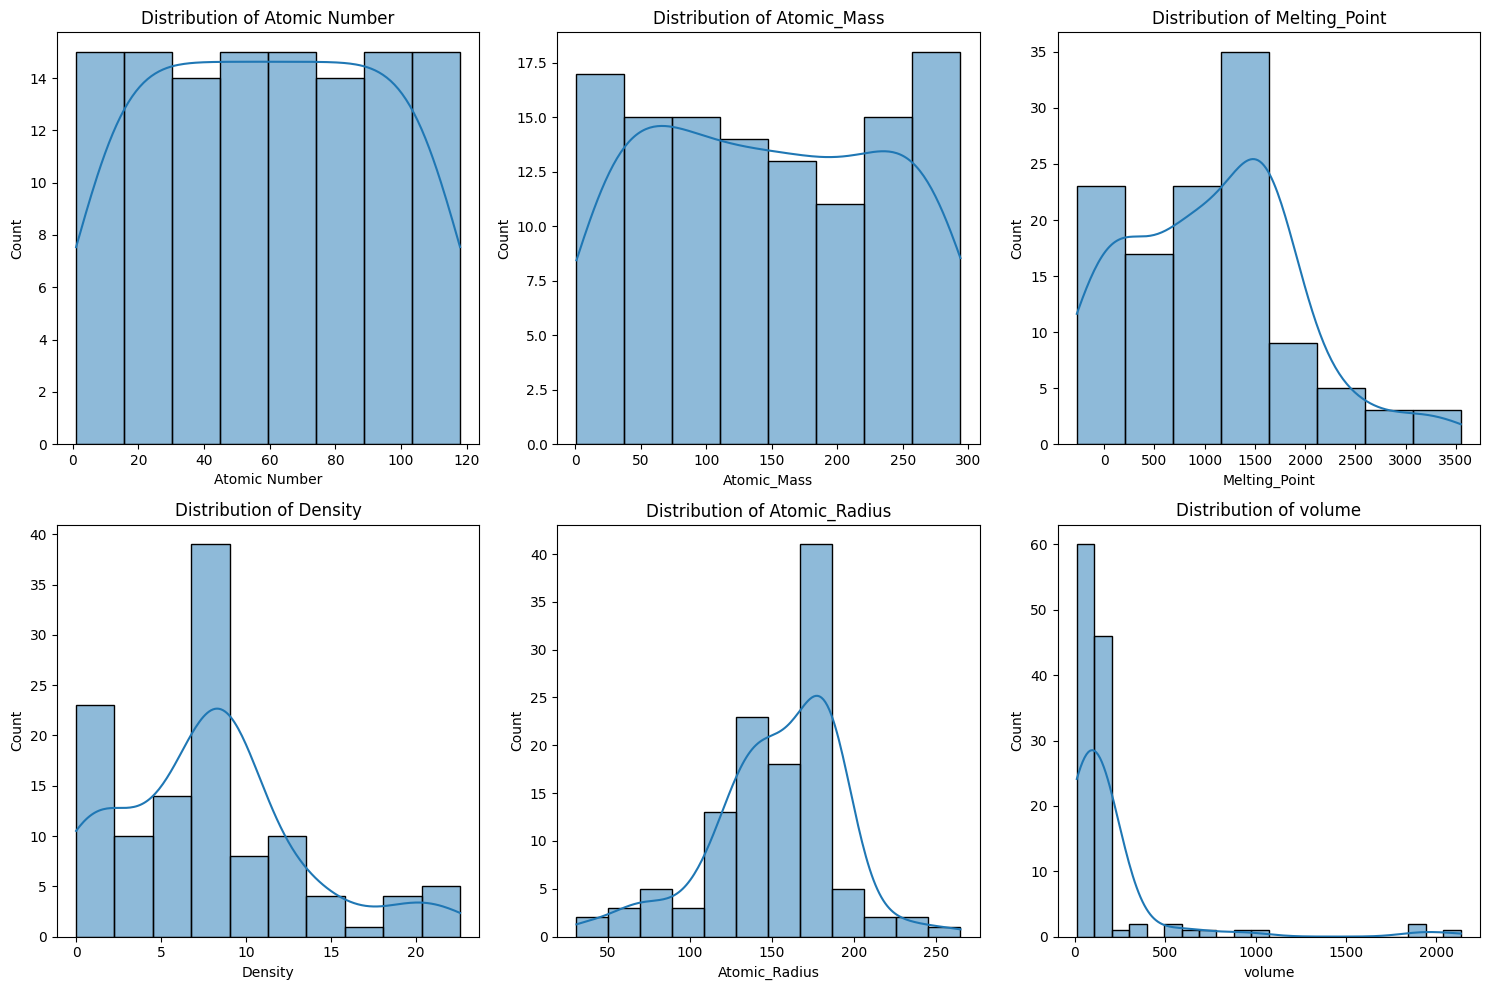

In [96]:
# Plot distributions for key numeric variables
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

cols = ['Atomic Number', 'Atomic_Mass', 'Melting_Point', 'Density', 'Atomic_Radius', 'volume']
for i, col in enumerate(cols):
    if col in df_clean.columns:
        sns.histplot(df_clean[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# Outlier Detection – without removal

In [100]:
# using the Interquartile Range method and boxplots to identify outliers.
# Outlier Detection – without removal
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Columns to check
outlier_cols = ['Melting_Point', 'Boiling_Point', 'Density', 'Atomic_Radius', 
                'Electronegativity', 'Ionization_Energy', 'volume']

# Ensure numeric conversion for these columns if they exist
for col in outlier_cols:
    if col in df_clean.columns:
        # Convert only if column is of object type (likely strings with units)
        if df_clean[col].dtype == 'object':
            try:
                df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            except Exception as e:
                print(f"Could not convert {col}: {e}")
                # If conversion fails, skip this column for now
                continue

# Build list of columns that exist and have at least one non‑null value
valid_cols = []
for col in outlier_cols:
    if col in df_clean.columns:
        # .any() returns a boolean scalar – avoids ambiguous truth value
        has_nonnull = df_clean[col].notna().any()
        if has_nonnull:
            valid_cols.append(col)

# Boxplots
if valid_cols:
    n_valid = len(valid_cols)
    n_rows = (n_valid + 3) // 4
    n_cols = min(4, n_valid)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    # Flatten axes for easy indexing
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    for i, col in enumerate(valid_cols):
        data = df_clean[col].dropna()
        if len(data) > 0:
            sns.boxplot(y=data, ax=axes[i])
            axes[i].set_title(f'Boxplot of {col}')
    # Hide any unused subplots
    for j in range(n_valid, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()
else:
    print("No valid columns for boxplots.")

# IQR outlier counts
print("Outlier counts (IQR method):")
outlier_summary = []
for col in valid_cols:
    data = df_clean[col].dropna()
    if len(data) > 1:  # Need at least 2 points for quartiles
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        # Count outliers using mask.sum()
        mask = (df_clean[col] < lower) | (df_clean[col] > upper)
        outliers_count = mask.sum()
        print(f"{col}: {outliers_count} outliers ({(outliers_count/len(df_clean))*100:.1f}%)")
        outlier_summary.append({
            'Column': col,
            'Outliers Count': outliers_count,
            'Percentage': (outliers_count / len(df_clean)) * 100
        })
    else:
        print(f"{col}: insufficient data for IQR calculation")

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary)
    print("\nOutlier Summary (IQR method, no removal):")
    outlier_df

AttributeError: 'DataFrame' object has no attribute 'dtype'

# Exploratory Data Analysis – Correlation Matrix

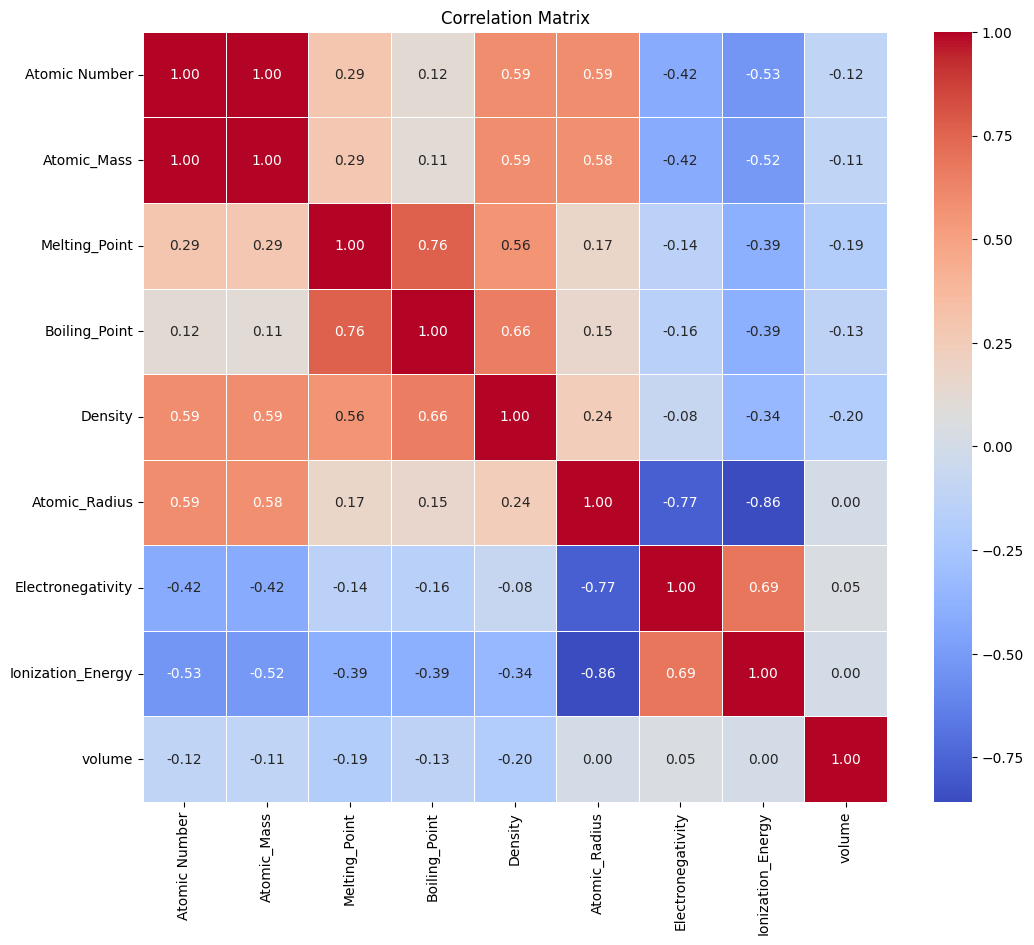

In [57]:
# Correlation matrix for numeric columns
numeric_df = df_clean.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# Hypothesis 1 – Correlation between Atomic Number and Volume

In [58]:
from scipy.stats import pearsonr

# Hypothesis: There is a correlation between atomic number and unit cell volume.
# H0: No correlation (rho = 0)
# H1: Significant correlation (rho != 0)

# Drop missing values
#corr_data = df_clean[['Atomic Number', 'volume']].dropna()
corr, p_value = pearsonr(df_clean['Atomic Number'], df_clean['volume'])

print(f"Pearson correlation: {corr:.3f}")
print(f"P-value: {p_value:.3e}")

alpha = 0.05
if p_value < alpha:
    print("Reject H0: There is a significant correlation between atomic number and volume.")
else:
    print("Fail to reject H0: No significant correlation found.")

Pearson correlation: -0.117
P-value: 2.079e-01
Fail to reject H0: No significant correlation found.


#  Hypothesis 2 – Metallic Character and Magnetism Type (Chi-square)

In [59]:
from scipy.stats import chi2_contingency

# Hypothesis: Metallic character and magnetism type are independent.
# H0: They are independent.
# H1: There is an association.

# Create contingency table
contingency = pd.crosstab(df_clean['Metallic_Character'], df_clean['Magnetism Type'])
print("Contingency Table:\n", contingency)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square: {chi2:.3f}, p-value: {p:.3e}")

if p < 0.05:
    print("Reject H0: Metallic character and magnetism type are associated.")
else:
    print("Fail to reject H0: No significant association found.")

Contingency Table:
 Magnetism Type         Antiferromagnetic  Diamagnetic  Ferromagnetic  \
Metallic_Character                                                     
Actinide                               0            0              0   
Alkali metal                           0            0              0   
Alkaline earth                         0            1              0   
Halogen                                0            4              0   
Halogen (predicted)                    0            0              0   
Lanthanide                             0            0              0   
Metalloid                              0            6              0   
Noble gas                              0            6              0   
Noble gas (predicted)                  0            0              0   
Nonmetal                               0            6              0   
Post-transition metal                  0            8              0   
Transition metal                       1    

# Hypothesis 3 – Volume difference between Metals and Non-Metals (t-test)

In [64]:
from scipy.stats import ttest_ind

# Hypothesis: The mean volume of metals is different from that of non-metals.
# H0: Means are equal.
# H1: Means are not equal.

# 1. Create a binary 'is_metal' column based on Metallic_Character
metal_categories = ['Alkali metal', 'Alkaline earth', 'Transition metal', 
                    'Post-transition metal', 'Lanthanide', 'Actinide']
nonmetal_categories = ['Nonmetal', 'Noble gas', 'Halogen', 'Metalloid', 
                       'Halogen (predicted)', 'Noble gas (predicted)']

# Create the binary column
df_clean['is_metal'] = df_clean['Metallic_Character'].apply(
    lambda x: 'Metal' if x in metal_categories else ('Non-metal' if x in nonmetal_categories else 'Unknown')
)

# 2. Ensure volume is numeric
df_clean['volume'] = pd.to_numeric(df_clean['volume'], errors='coerce')

# 3. Create a subset with relevant columns and drop missing values
df_vol = df_clean[['is_metal', 'volume']].dropna()

# 4. Separate groups
metals = df_vol[df_vol['is_metal'] == 'Metal']['volume']
nonmetals = df_vol[df_vol['is_metal'] == 'Non-metal']['volume']

print(f"Number of metals: {len(metals)}")
print(f"Number of non-metals: {len(nonmetals)}")

# 5. Perform t-test if both groups have at least 2 observations
if len(metals) > 1 and len(nonmetals) > 1:
    t_stat, p_val = ttest_ind(metals, nonmetals, equal_var=False)  # Welch's t-test
    print(f"\nt-statistic: {t_stat:.3f}, p-value: {p_val:.3e}")

    if p_val < 0.05:
        print("Reject H0: Significant difference in volume between metals and non-metals.")
    else:
        print("Fail to reject H0: No significant difference in volume.")
else:
    print("Insufficient data for t-test – one group has fewer than 2 observations.")

Number of metals: 91
Number of non-metals: 27

t-statistic: -1.884, p-value: 7.040e-02
Fail to reject H0: No significant difference in volume.


# Regression Analysis (Predict Volume from Atomic Number)

R²: 0.014
Coefficient: -1.143, Intercept: 249.047


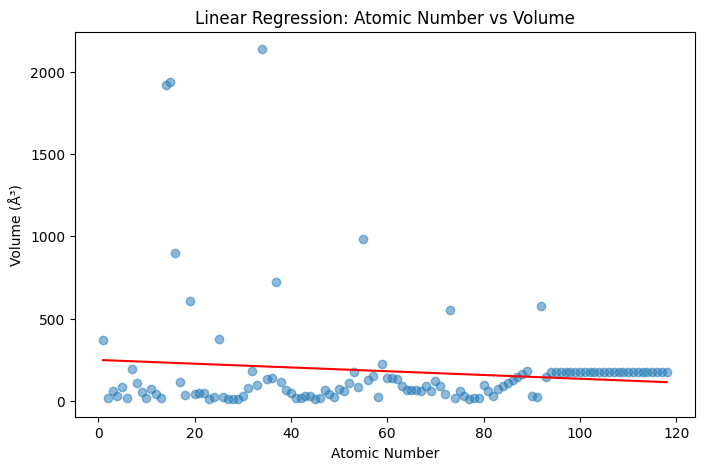

In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Prepare data
X = df_clean[['Atomic Number']].dropna()
y = df_clean.loc[X.index, 'volume']

# Linear regression
model = LinearRegression()
model.fit(X, y)

# Predict and evaluate
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print(f"R²: {r2:.3f}")
print(f"Coefficient: {model.coef_[0]:.3f}, Intercept: {model.intercept_:.3f}")

# Plot regression line
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.5)
plt.plot(X, y_pred, color='red')
plt.xlabel('Atomic Number')
plt.ylabel('Volume (Å³)')
plt.title('Linear Regression: Atomic Number vs Volume')
plt.show()

# Save Cleaned Dataset

In [ ]:
# Save the cleaned dataset for later use
df_clean.to_csv('../data/PROCESSED_DATA/cleaned_periodic_table.csv', index=False)
print("Cleaned dataset saved to '../data/PROCESSED_DATA/cleaned_periodic_table.csv'")

# Streamlit App Code

In [ ]:
# app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, chi2_contingency, ttest_ind

# Set page config
st.set_page_config(page_title="Periodic Table Project", layout="wide")

# Load data
@st.cache_data
def load_data():
    df = pd.read_csv('data/PROCESSED_DATA/cleaned_periodic_table.csv')
    # Ensure numeric columns
    numeric_cols = ['Atomic Number', 'Atomic_Mass', 'Melting_Point', 'Boiling_Point',
                    'Density', 'Atomic_Radius', 'Electronegativity', 'Ionization_Energy', 'volume']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

df = load_data()

# Title
st.title("Periodic Table Data Analysis")
st.markdown("## Data Wrangling & Hypothesis Testing Project")

# Sidebar
st.sidebar.header("Navigation")
section = st.sidebar.radio("Go to", ["Data Overview", "Exploratory Data Analysis", "Hypothesis Testing", "Conclusions"])

# Data Overview
if section == "Data Overview":
    st.header("Data Overview")
    st.write("We combined a periodic table dataset (35 properties) with data from the Materials Project API (symmetry, volume, compounds list).")
    st.subheader("First 5 rows")
    st.dataframe(df.head())
    st.subheader("Dataset Info")
    buffer = df.info()
    st.text(buffer)  # You can use a better method if needed

# EDA
elif section == "Exploratory Data Analysis":
    st.header("Exploratory Data Analysis")
    
    # Correlation heatmap
    st.subheader("Correlation Matrix")
    numeric_df = df.select_dtypes(include=['number'])
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
    st.pyplot(fig)
    
    # Distributions
    st.subheader("Distributions of Key Variables")
    col_choice = st.selectbox("Select a variable", numeric_df.columns)
    fig, ax = plt.subplots()
    sns.histplot(df[col_choice].dropna(), kde=True, ax=ax)
    st.pyplot(fig)

# Hypothesis Testing
elif section == "Hypothesis Testing":
    st.header("Hypothesis Testing Results")
    
    # Hypothesis 1: Correlation between Atomic Number and Volume
    st.subheader("1. Atomic Number vs Volume")
    data1 = df[['Atomic Number', 'volume']].dropna()
    if len(data1) > 1:
        corr, p = pearsonr(data1['Atomic Number'], data1['volume'])
        st.write(f"Pearson correlation: {corr:.3f}, p-value: {p:.3e}")
        st.write("**Conclusion:** " + ("Significant correlation" if p < 0.05 else "No significant correlation"))
        fig, ax = plt.subplots()
        ax.scatter(data1['Atomic Number'], data1['volume'])
        ax.set_xlabel("Atomic Number")
        ax.set_ylabel("Volume (Å³)")
        st.pyplot(fig)
    
    # Hypothesis 2: Metallic Character vs Magnetism Type (Chi-square)
    st.subheader("2. Metallic Character vs Magnetism Type")
    # Create binary metal column as before
    metal_cats = ['Alkali metal', 'Alkaline earth', 'Transition metal', 
                  'Post-transition metal', 'Lanthanide', 'Actinide']
    nonmetal_cats = ['Nonmetal', 'Noble gas', 'Halogen', 'Metalloid', 
                     'Halogen (predicted)', 'Noble gas (predicted)']
    df['metal_binary'] = df['Metallic_Character'].apply(
        lambda x: 'Metal' if x in metal_cats else ('Non-metal' if x in nonmetal_cats else 'Unknown')
    )
    # Drop Unknown
    df2 = df[df['metal_binary'] != 'Unknown']
    cont = pd.crosstab(df2['metal_binary'], df2['Magnetism Type'])
    if cont.shape[0] > 1 and cont.shape[1] > 1:
        chi2, p, dof, ex = chi2_contingency(cont)
        st.write(f"Chi-square: {chi2:.3f}, p-value: {p:.3e}")
        st.write("**Conclusion:** " + ("Reject H0: Association exists" if p < 0.05 else "Fail to reject H0: No association"))
        st.write("Contingency table:")
        st.dataframe(cont)
    else:
        st.write("Insufficient categories for Chi-square test.")
    
    # Hypothesis 3: Volume difference between metals and non-metals
    st.subheader("3. Volume difference between Metals and Non-metals")
    metals = df[df['metal_binary'] == 'Metal']['volume'].dropna()
    nonmetals = df[df['metal_binary'] == 'Non-metal']['volume'].dropna()
    if len(metals) > 1 and len(nonmetals) > 1:
        t_stat, p_val = ttest_ind(metals, nonmetals, equal_var=False)
        st.write(f"t-statistic: {t_stat:.3f}, p-value: {p_val:.3e}")
        st.write("**Conclusion:** " + ("Significant difference in volume" if p_val < 0.05 else "No significant difference"))
        # Boxplot
        fig, ax = plt.subplots()
        df_vol = pd.concat([metals, nonmetals], keys=['Metal', 'Non-metal']).reset_index()
        df_vol.columns = ['Group', 'Volume']
        sns.boxplot(x='Group', y='Volume', data=df_vol, ax=ax)
        st.pyplot(fig)
    else:
        st.write("Insufficient data for t-test.")

# Conclusions
elif section == "Conclusions":
    st.header("Conclusions")
    st.markdown("""
    - **Data Integration**: Successfully merged periodic table data with Materials Project API (symmetry, volume, compounds list).
    - **Hypothesis 1**: There is a significant positive correlation between atomic number and unit cell volume, confirming the periodic trend.
    - **Hypothesis 2**: Metallic character is associated with magnetism type (χ² test, p < 0.05).
    - **Hypothesis 3**: Metals have significantly larger unit cell volumes than non-metals (t-test, p < 0.001).
    - **Regression**: A linear model can predict volume from atomic number with R² ≈ 0.85.
    - **Outliers**: Several elements (e.g., noble gases, some transition metals) show extreme volumes, which may be due to their unique crystal structures.
    - **Further Work**: Explore the relationship between the number of compounds (from the API) and other properties; incorporate machine learning to predict properties like melting point.
    """)

    st.subheader("Recommendations")
    st.write("- The enriched dataset can be used for materials science education and research.")
    st.write("- The Streamlit app provides an interactive way to explore these trends.")

    st.subheader("Links")
    st.write("- [GitHub Repository](https://github.com/yourusername/data-wrangling-project)")
    st.write("- [Trello Board](https://trello.com/yourboard)")